# Quick Start

In addition to quantum circuit execution IQM Client allows the user to build and execute pulse-level instruction schedules on a quantum computer. Within the existing IQM QCCSW stack, this *pulse-level access* is somewhere between circuit-level execution and dedicated calibration experiments. Namely, with pulse level access the user can:

- compile a quantum circuit (e.g. from Qiskit) into an instruction schedule on the client side
- access and modify the calibration data to be used for the circuit-to-schedule compilation
- view and modify the default implementations of quantum gates, using e.g. custom pulse shapes
- define custom implementations of quantum gates
- define new composite gates out of native gates and set their calibration data
- control the multi-step compilation procedure, and edit the intermediate data
- construct instruction schedules manually

This notebook contains a small meaningful example for a "quick start". Refer to other chapters for more details on various aspects of pulse-level access.

## Authentication

The preferred way to provide the connection and authentication information to IQMClient is using **environment variables**.

* IQMClient connects to the quantum computer using the URL in the environment variable `IQM_SERVER_URL`.
* IQM Server uses bearer token authentication to manage access to quantum computers.
  Get your personal token from the IQM Server web dashboard and store it in the environment variable `IQM_TOKEN`, where IQMClient will find it.
* For IQM Server instances that manage more than one quantum computer you need to also provide the name of the quantum computer in the environment variable `IQM_QUANTUM_COMPUTER`.

Alternatively, the connection and authentication information can be provided as environment variables
set inside the notebook using
```python
import os
os.environ["IQM_SERVER_URL"] = "<IQM Server URL>"
os.environ["IQM_QUANTUM_COMPUTER"] = "<quantum computer name>"
os.environ["IQM_TOKEN"] = "<your API token>"
```
However, this is not recommended since this way it is easy to accidentally expose your API token e.g. when giving a presentation or by committing the notebook with the API token to a shared code repository.

## Using pulse-level access with IQM Resonance

Pulse-level access is also available on the [IQM Resonance](https://iqm.tech/products/iqm-resonance) cloud service. You need to set `IQM_SERVER_URL` to point to Resonance (https://resonance.iqm.tech), and specify the quantum computer to use in `IQM_QUANTUM_COMPUTER`.

The names of the available quantum computers can be found on the Resonance dashboard.

In [1]:
from qiskit import QuantumCircuit, visualization
from qiskit.compiler import transpile
from iqm.iqm_client.util import print_env_vars
from iqm.qiskit_iqm import IQMProvider
from iqm.qiskit_iqm.pulse_level_utils import sweep_job_to_qiskit, qiskit_to_iqm

In [ ]:
print_env_vars()

# Create a qiskit-iqm backend for accessing the quantum computer, containing an IQMClient instance.
# Calling IQMProvider.get_backend() will initialize the required IQMClient instance from environment
# variables by calling IQMClient.from_url().
provider = IQMProvider()
backend = provider.get_backend()
iqm_client = backend.client

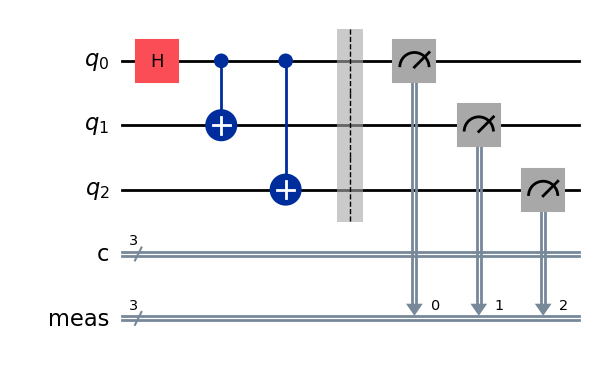

In [3]:
# Define a quantum circuit.
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.measure_all()

qc.draw(output='mpl')

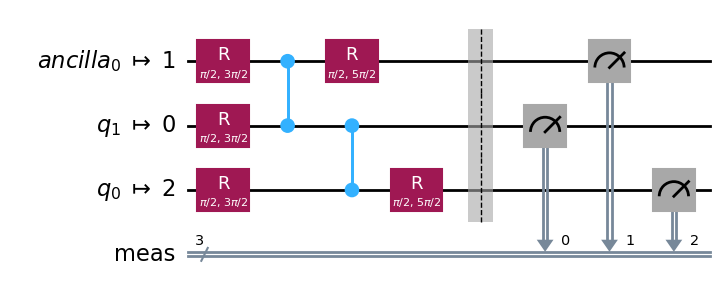

In [4]:
# Transpile the circuit using Qiskit
qc_transpiled = transpile(qc, backend=backend, layout_method='sabre', optimization_level=3)
qc_transpiled.draw(output="mpl")

In [5]:
# Convert it into IQM format
circuits, compiler = qiskit_to_iqm(backend, qc_transpiled)

# Set the number of shots
shots = 100
settings = compiler.get_settings(circuits=circuits)
settings.set_shots(shots)

# Compile the circuit into a job definition containing a playlist of instruction schedules.
run_definition, context = compiler.compile(circuits, settings=settings)

In [ ]:
# IQMClient.submit_playlist() returns an object that tracks the state of the job on the server.
# The measurements are obtained using job_tracker.result() after job_tracker.wait_for_completion().
job_tracker = iqm_client.submit_playlist(run_definition, context=context)
job_tracker.wait_for_completion()
qiskit_result = sweep_job_to_qiskit(job_tracker, shots=shots)

print(f"Raw results:\n{job_tracker.result().circuit_measurement_results}\n")
print(f"Qiskit result counts:\n{qiskit_result.get_counts()}\n")
visualization.plot_histogram(qiskit_result.get_counts())

In [ ]:
# Convert it into IQM format
circuits, compiler = qiskit_to_iqm(backend, qc_transpiled)

# Set the number of shots
shots = 100
settings = compiler.get_settings(circuits=circuits)
settings.set_shots(shots)

# Compile the circuit into a job definition containing a playlist of instruction schedules.
run_definition, context = compiler.compile(circuits, settings=settings)

In [ ]:
# The results should be comparable to a direct circuit execution through IQM Server.
print("Executing the same circuit via the Qiskit backend...")
iqm_job = backend.run(qc_transpiled, shots=shots)
print(f"Qiskit result counts from IQM Server:\n{iqm_job.result().get_counts()}")

visualization.plot_histogram(iqm_job.result().get_counts())

# Schedule visualization

IQM Pulse comes with a schedule visualizer. It takes a Playlist (i.e. a compressed list of instruction schedules) and a list of schedule/segment indices to inspect.
The `playlist` variable below is the one which we derived from the original Qiskit circuit using the IQM circuit-to-pulse compiler, and it only has one schedule.

In [ ]:
from iqm.pulse.playlist.visualisation.base import inspect_playlist
from IPython.core.display import HTML

HTML(inspect_playlist(run_definition.sweep_definition.playlist, [0]))